# Temperature Evolution In Germany

In [ ]:
from matplotlib import pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as ticker
import pandas as pd
import xarray as xr
import numpy as np
import os

: 

## Monthly Temperature Evolution

In [ ]:
data = 'De_Temp_ts.nc'
ds = xr.open_dataset(data)
df = ds.to_dataframe().reset_index()
df = df.drop(['lon'], axis=1)
df = df.drop(['lat'], axis=1)

In [ ]:
df['months'] = df['valid_time'].dt.month
df['years'] = df['valid_time'].dt.year
df

,valid_time,t2m,months,years
0,1940-01-01,-8.404455,1,1940
1,1940-02-01,-4.164541,2,1940
2,1940-03-01,2.439169,3,1940
3,1940-04-01,7.332013,4,1940
4,1940-05-01,11.463957,5,1940
...,...,...,...,...
1025,2025-06-01,18.087135,6,2025
1026,2025-07-01,18.140566,7,2025
1027,2025-08-01,18.057981,8,2025
1028,2025-09-01,14.644297,9,2025


In [ ]:
df['t2m'].describe()

,t2m
count,1030.000000
mean,8.589828
std,6.531808
min,-9.182904
25%,3.070031
50%,8.453108
75%,14.522779
max,21.599279


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1030 entries, 0 to 1029
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   valid_time  1030 non-null   datetime64[ns]
 1   t2m         1030 non-null   float32       
 2   months      1030 non-null   int32         
 3   years       1030 non-null   int32         
dtypes: datetime64[ns](1), float32(1), int32(2)
memory usage: 20.2 KB


In [ ]:
ds['t2m']

<xarray.DataArray 't2m' (valid_time: 1030, lat: 1, lon: 1)> Size: 4kB
array([[[-8.404455]],

       [[-4.164541]],

       ...,

       [[14.644297]],

       [[ 9.791244]]], dtype=float32)
Coordinates:
  * valid_time  (valid_time) datetime64[ns] 8kB 1940-01-01 ... 2025-10-01
  * lat         (lat) float64 8B 0.0
  * lon         (lon) float64 8B 0.0
Attributes: (12/32)
    standard_name:                            unknown
    long_name:                                2 metre temperature
    units:                                    K
    GRIB_paramId:                             167
    GRIB_dataType:                            an
    GRIB_numberOfPoints:                      1485
    ...                                       ...
    GRIB_missingValue:                        3.4028234663852886e+38
    GRIB_name:                                2 metre temperature
    GRIB_shortName:                           2t
    GRIB_totalNumber:                         0
    GRIB_units:                               K
    GRIB_surface:                             0.0

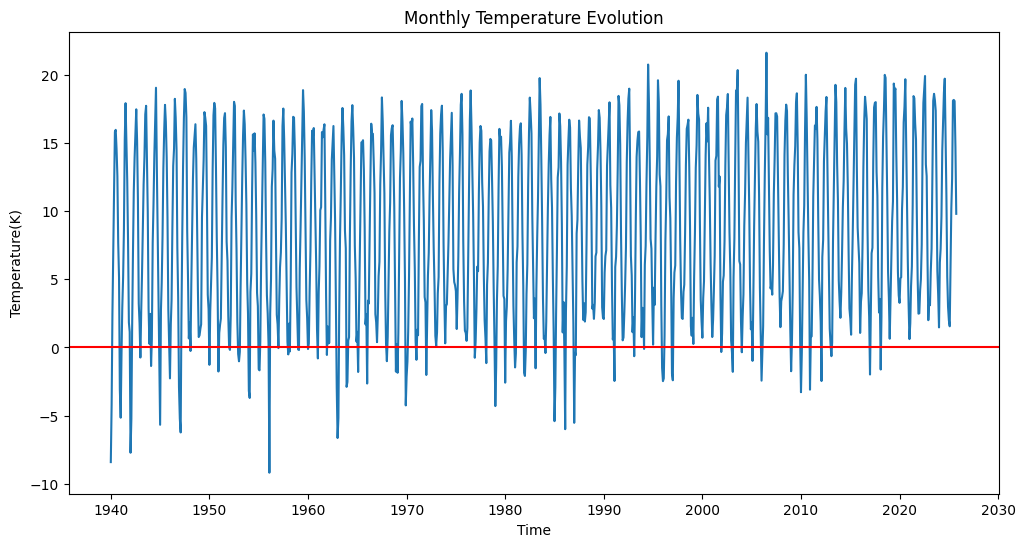

In [ ]:
plt.figure(figsize=(12, 6))
plt.plot(df['valid_time'], df['t2m'])
plt.xlabel('Time')
plt.ylabel('Temperature(K)')
plt.title('Monthly Temperature Evolution')
plt.axhline(y=0.0, color='r')
plt.savefig('Monthly_Temperature_Evolution.png')
plt.show()

### Adding a regression line

In [ ]:
len(df['months'])

1030

In [ ]:
coefficients_mnt = np.polyfit(df.index, df['t2m'], 1)
reg_mnts = np.poly1d(coefficients_mnt)
print('y =', reg_mnts)

y =  
0.002332 x + 7.39


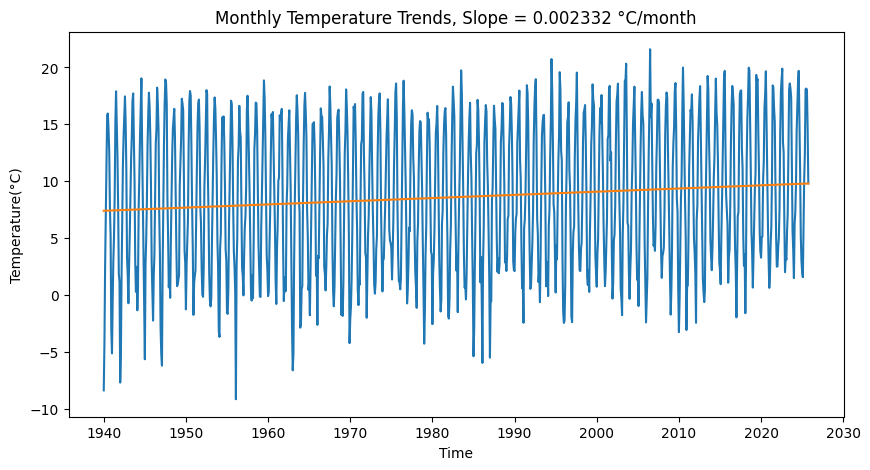

In [ ]:
plt.figure(figsize=(10, 5))
plt.plot(df['valid_time'], df['t2m'])
plt.plot(df['valid_time'], reg_mnts(df.index))
plt.xlabel('Time')
plt.ylabel('Temperature(\u00B0C)')
plt.title('Monthly Temperature Trends, Slope = 0.002332 \u00B0C/month')
#plt.axhline(y=0.0, color='r')
plt.savefig('Monthly_Temperature_regression.png')
plt.show()

## Seasonal (Summer vs Winter) Evolution

In [ ]:
!pip install pandasql
from pandasql import sqldf

  Preparing metadata (setup.py) ... done
  Created wheel for pandasql: filename=pandasql-0.7.3-py3-none-any.whl size=26773 sha256=3c954388f18b8ee1b66fa85ab5803b894b53886c46626c5cd4efbd5f1ca8fac8
  Stored in directory: /root/.cache/pip/wheels/15/a1/e7/6f92f295b5272ae5c02365e6b8fa19cb93f16a537090a1cf27
Successfully built pandasql


In [ ]:
# Selecting winter season and averaging over the years
df_winter_mean = "SELECT years, AVG(t2m) as avg_temp FROM df WHERE months IN (12, 1, 2) GROUP BY years ORDER BY years"
df_winter_mean = sqldf(df_winter_mean, locals())

# Selecting summer season and averaging over the years
df_summer_mean = "SELECT years, AVG(t2m) as avg_temp FROM df WHERE months IN (6, 7, 8) GROUP BY years ORDER BY years"
df_summer_mean = sqldf(df_summer_mean, locals())

In [ ]:
df_summer_mean.head()

,years,avg_temp
0,1940,15.433679
1,1941,16.066431
2,1942,15.706528
3,1943,16.253335
4,1944,16.566912


In [ ]:
df_winter_mean.head()

,years,avg_temp
0,1940,-5.216327
1,1941,-1.495965
2,1942,-3.724470
3,1943,0.739030
4,1944,0.060861


In [ ]:
#summer_years = mdates.date2num(df_summer_mean['years'])
coefficients_sum = np.polyfit(df_summer_mean.index, df_summer_mean['avg_temp'], 1)
reg_sum = np.poly1d(coefficients_sum)
print(reg_sum)

 
0.02446 x + 15.63


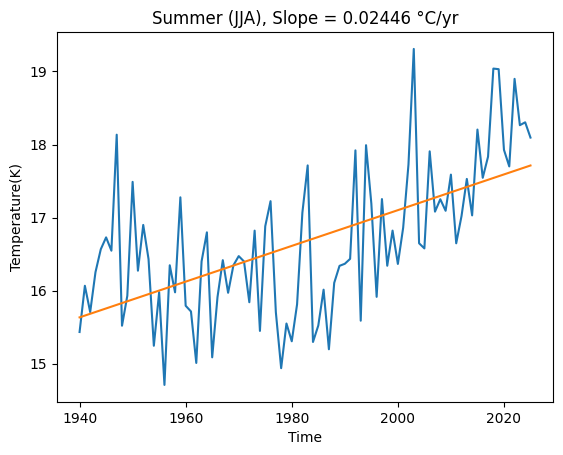

In [ ]:
plt.plot(df_summer_mean['years'], df_summer_mean['avg_temp'])
plt.plot(df_summer_mean['years'], reg_sum(df_summer_mean.index))
plt.xlabel('Time')
plt.ylabel('Temperature(K)')
plt.title('Summer (JJA), Slope = 0.02446 \u00B0C/yr')
plt.savefig('Summer_regression.png')
plt.show()

In [ ]:
# winter regression
coefficients_win = np.polyfit(df_winter_mean.index, df_winter_mean['avg_temp'], 1)
reg_win = np.poly1d(coefficients_win)
print(reg_win)

 
0.04035 x - 1.143


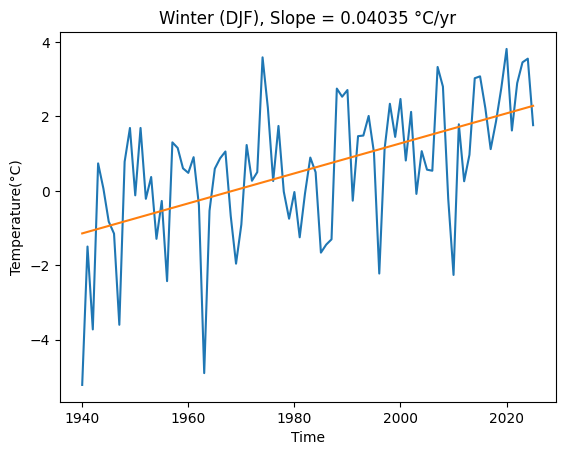

In [ ]:

plt.plot(df_winter_mean['years'], df_winter_mean['avg_temp'])
plt.plot(df_winter_mean['years'], reg_win(df_winter_mean.index))
plt.xlabel('Time')
plt.ylabel('Temperature(\u00B0C)')
plt.title('Winter (DJF), Slope = 0.04035 \u00B0C/yr')
plt.savefig('Winter_regression.png')
plt.show()

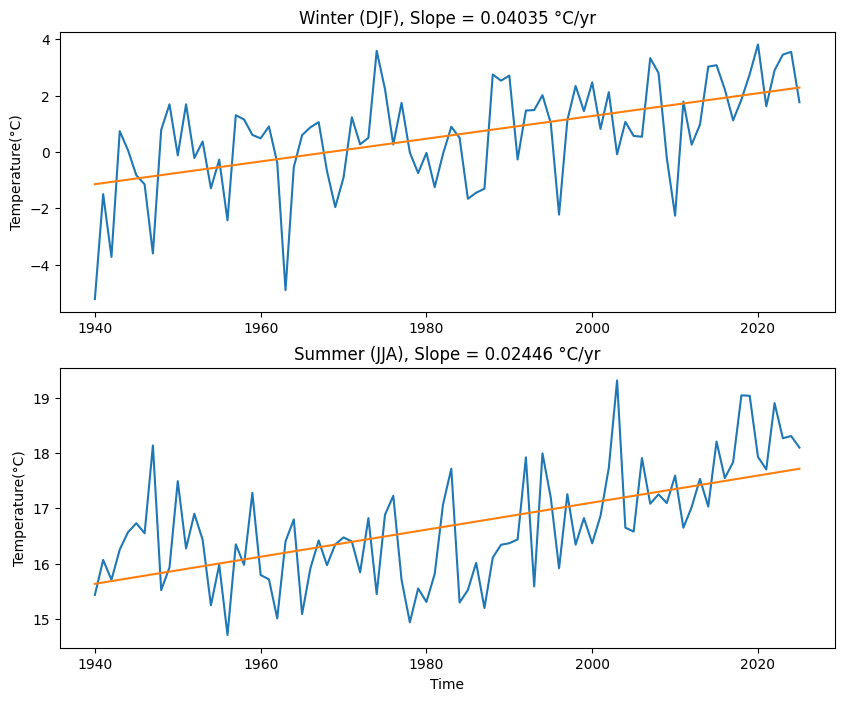

In [ ]:
# Plotting both seasons on one graph
plt.figure(figsize=(10, 8))
plt.subplot(2, 1, 1)
plt.plot(df_winter_mean['years'], df_winter_mean['avg_temp'])
plt.plot(df_winter_mean['years'], reg_win(df_winter_mean.index))
#plt.xlabel('Time')
plt.ylabel('Temperature(\u00B0C)')
plt.title('Winter (DJF), Slope = 0.04035 \u00B0C/yr')

plt.subplot(2, 1, 2)
plt.plot(df_summer_mean['years'], df_summer_mean['avg_temp'])
plt.plot(df_summer_mean['years'], reg_sum(df_summer_mean.index))
plt.xlabel('Time')
plt.ylabel('Temperature(\u00B0C)')
plt.title('Summer (JJA), Slope = 0.02446 \u00B0C/yr')
plt.savefig('Summer_Winter_regression.png')
plt.show()

## Yearly Temperature Evolution

In [ ]:
df_yrs = df.groupby(df['valid_time'].dt.year)['t2m'].mean()
df_yrs = df_yrs.reset_index()
df_yrs = df_yrs[:-1]
df_yrs.head()

,valid_time,t2m
0,1940,6.437180
1,1941,6.849239
2,1942,7.073747
3,1943,8.640604
4,1944,7.873053


In [ ]:
df_yrs['t2m'].describe()

,t2m
count,85.000000
mean,8.565550
std,0.931086
min,6.437180
25%,7.869608
50%,8.640604
75%,9.157813
max,10.700016


In [ ]:
years = df_yrs['valid_time']
coefficients = np.polyfit(df_yrs.index, df_yrs['t2m'], 1)
reg_ym = np.poly1d(coefficients)
print(reg_ym)

 
0.02628 x + 7.462


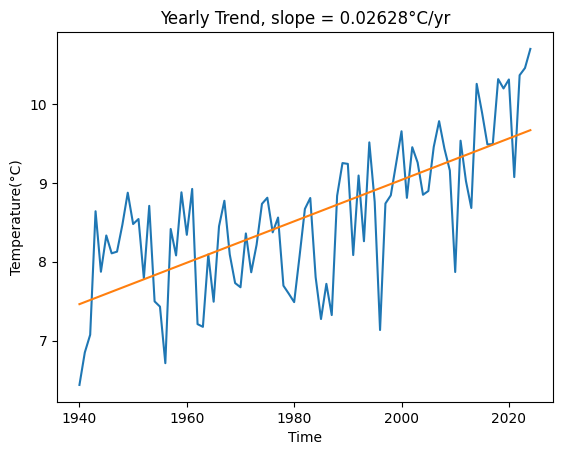

In [ ]:

plt.plot(df_yrs['valid_time'], df_yrs['t2m'])
plt.plot(years, reg_ym(df_yrs.index))
plt.xlabel('Time')
plt.ylabel('Temperature(\u00B0C)')
plt.title('Yearly Trend, slope = 0.02628\u00B0C/yr')
plt.show()

## 30 years Rolling Average

In [ ]:
df_yrs_30 = df_yrs.rolling(window=30).mean()
df_yrs_30 = df_yrs_30.dropna()
df_yrs_30.head()

,valid_time,t2m
29,1954.5,7.986719
30,1955.5,8.028018
31,1956.5,8.078343
32,1957.5,8.104766
33,1958.5,8.090588


In [ ]:
plt.plot(df_yrs_30['valid_time'], df_yrs_30['t2m'])
plt.xlabel('Time')
plt.ylabel('Temperature(\u00B0C)')
plt.title('30 years Moving Average')
plt.savefig('30_years_rolling_average.png')
plt.show()

# Heatmap of temperature over Germany

In [ ]:
!pip install cartopy

import cartopy.crs as ccrs

In [ ]:
data = 'DE_Temp_Time_Mean.nc'
ds = xr.open_dataset(data)
df = ds.to_dataframe().reset_index()
df

,valid_time,bnds,latitude,longitude,valid_time_bnds,t2m
0,1982-11-16,0,55.0,5.00,1940-01-01,282.860016
1,1982-11-16,0,55.0,5.25,1940-01-01,282.865326
2,1982-11-16,0,55.0,5.50,1940-01-01,282.871918
3,1982-11-16,0,55.0,5.75,1940-01-01,282.875397
4,1982-11-16,0,55.0,6.00,1940-01-01,282.875824
...,...,...,...,...,...,...
2965,1982-11-16,1,47.0,15.00,2025-10-01,279.783081
2966,1982-11-16,1,47.0,15.25,2025-10-01,281.193481
2967,1982-11-16,1,47.0,15.50,2025-10-01,282.161530
2968,1982-11-16,1,47.0,15.75,2025-10-01,282.808838


In [ ]:
ds['t2m']

<xarray.DataArray 't2m' (valid_time: 1, latitude: 33, longitude: 45)> Size: 6kB
array([[[282.86002, 282.86533, ..., 281.63834, 281.6206 ],
        [282.96255, 282.9632 , ..., 281.67734, 281.65796],
        ...,
        [283.73206, 284.22644, ..., 281.42862, 281.82034],
        [284.30392, 284.4918 , ..., 282.80884, 282.90674]]], dtype=float32)
Coordinates:
  * valid_time  (valid_time) datetime64[ns] 8B 1982-11-16
  * latitude    (latitude) float64 264B 55.0 54.75 54.5 ... 47.5 47.25 47.0
  * longitude   (longitude) float64 360B 5.0 5.25 5.5 5.75 ... 15.5 15.75 16.0
Attributes: (12/33)
    standard_name:                            unknown
    long_name:                                2 metre temperature
    units:                                    K
    cell_methods:                             valid_time: mean
    GRIB_paramId:                             167
    GRIB_dataType:                            an
    ...                                       ...
    GRIB_missingValue:                        3.4028234663852886e+38
    GRIB_name:                                2 metre temperature
    GRIB_shortName:                           2t
    GRIB_totalNumber:                         0
    GRIB_units:                               K
    GRIB_surface:                             0.0

In [ ]:
ds['longitude']

<xarray.DataArray 'longitude' (longitude: 45)> Size: 360B
array([ 5.  ,  5.25,  5.5 ,  5.75,  6.  ,  6.25,  6.5 ,  6.75,  7.  ,  7.25,
        7.5 ,  7.75,  8.  ,  8.25,  8.5 ,  8.75,  9.  ,  9.25,  9.5 ,  9.75,
       10.  , 10.25, 10.5 , 10.75, 11.  , 11.25, 11.5 , 11.75, 12.  , 12.25,
       12.5 , 12.75, 13.  , 13.25, 13.5 , 13.75, 14.  , 14.25, 14.5 , 14.75,
       15.  , 15.25, 15.5 , 15.75, 16.  ])
Coordinates:
  * longitude  (longitude) float64 360B 5.0 5.25 5.5 5.75 ... 15.5 15.75 16.0
Attributes:
    standard_name:  longitude
    long_name:      longitude
    units:          degrees_east
    axis:           X

In [ ]:
ds['latitude']

<xarray.DataArray 'latitude' (latitude: 33)> Size: 264B
array([55.  , 54.75, 54.5 , 54.25, 54.  , 53.75, 53.5 , 53.25, 53.  , 52.75,
       52.5 , 52.25, 52.  , 51.75, 51.5 , 51.25, 51.  , 50.75, 50.5 , 50.25,
       50.  , 49.75, 49.5 , 49.25, 49.  , 48.75, 48.5 , 48.25, 48.  , 47.75,
       47.5 , 47.25, 47.  ])
Coordinates:
  * latitude  (latitude) float64 264B 55.0 54.75 54.5 54.25 ... 47.5 47.25 47.0
Attributes:
    standard_name:  latitude
    long_name:      latitude
    units:          degrees_north
    axis:           Y

In [ ]:
import cartopy

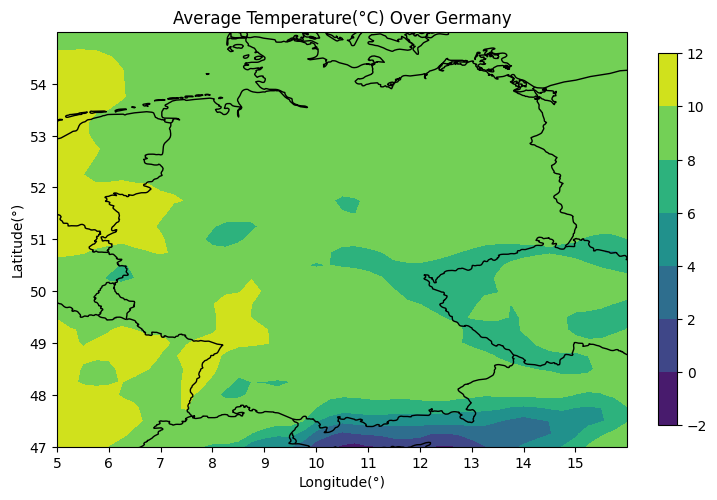

In [ ]:
plt.figure(figsize=(8, 10))
ax = plt.axes(projection=ccrs.PlateCarree())
ax.coastlines()
ax.add_feature(cartopy.feature.BORDERS)
plt.contourf(ds['longitude'], ds['latitude'], ds['t2m'][0,:,:]-273)
plt.colorbar(fraction=0.03)
plt.xticks(np.arange(5.0,16.0, step=1))
plt.yticks(np.arange(47.0,55.0, step=1))
plt.xlabel('Longitude(\u00B0)')
plt.ylabel('Latitude(\u00B0)')
plt.title('Average Temperature(\u00B0C) Over Germany')
plt.savefig('heatmap.png')
plt.show()